# Installing The Requirements

In [ ]:
%pip install matplotlib numpy pandas

Looking in indexes: https://mirror-pypi.runflare.com/simple
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Synthetic Data Generation

## Hyperparameter Definitions

In [18]:
import numpy as np
# Compounded return equation params
y_0 = 5
beta_0 = 0
beta_1 =0.2
beta_2 = 0.01
# Volatility equation params
mu = 0.5
phi = 0.6
sigma_nu = 1
np.random.seed(56)
h_1 = np.random.normal(mu, (sigma_nu**2)/(1-phi**2)) # the stationary distribution of AR(1) process

## Simulation

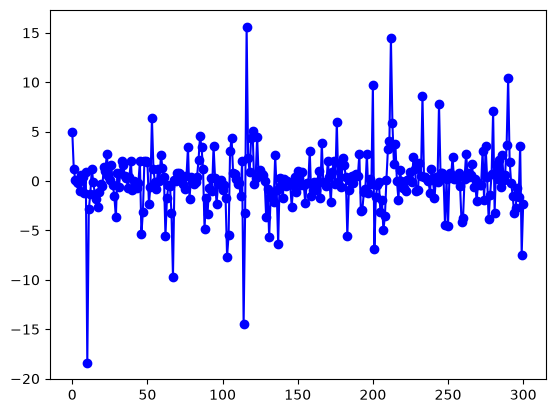

In [19]:
import matplotlib.pyplot as plt
import numpy as np


n_steps = 300
x_array = np.arange(n_steps + 1)
y_array = np.empty(n_steps + 1)
h_array = np.empty(n_steps + 1)

y_array[0] = y_0
h_array[0] = h_1

eps = np.random.standard_t(df=3, size=n_steps)
eta = np.random.normal(size=n_steps)

for t in range(1, n_steps + 1):
    h_array[t] = mu + phi * (h_array[t-1] - mu) + sigma_nu * eta[t-1]
    y_array[t] = (
        beta_0
        + beta_1 * y_array[t-1]
        + beta_2 * np.exp(h_array[t-1])
        + np.exp(h_array[t-1] / 2) * eps[t-1]
    )

# plot x and y
plt.plot(x_array, y_array, label="y_t", color="blue", marker="o")
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame({"x": x_array, "y": y_array, "h": h_array})

In [20]:
df.to_csv("svm_simulation.csv", index=False)